# Qwen3-VL-4B (Qwen3 Vision-Language) 사용 예제

[Qwen3-VL](https://huggingface.co/Qwen/Qwen3-VL-4B-Instruct)은 Alibaba Qwen 시리즈의 최신 **비전-언어 모델(VLM)** 입니다.
LLaVA와 달리 **한국어를 포함한 32개 언어** OCR·대화를 네이티브로 지원하며, 4B 파라미터로 **12GB VRAM** 환경에서도 실행하기 쉽습니다.

논문: [Qwen3 Technical Report](https://arxiv.org/abs/2505.09388)

이 노트북에서 다루는 내용:
1. Qwen3-VL-4B-Instruct 모델 로드 (`Qwen/Qwen3-VL-4B-Instruct`)
2. **이미지 설명** — 한국어·영어 단일 턴 질의응답
3. **Visual Question Answering (VQA)** — 한국어 질문으로 세부 정보 확인
4. **다중 턴 대화** — 맥락을 이어가며 후속 질문
5. **지시 따르기** — 객체 나열, 개수 세기 등
6. **배치 추론** — 여러 이미지에 동일 질문 적용
7. **LLaVA vs Qwen3-VL 비교 요약**

> 이전 노트북: `04_llava_example.ipynb` (LLaVA-7B, 영어 중심) · `05_llava_qlora_mini_train.ipynb` (QLoRA 학습)


## 1. 환경 설정

터미널에서 의존성을 설치합니다.

```bash
pip install -r requirements.txt
```

Qwen3-VL은 **transformers 4.57.0 이상**이 필요합니다.

```
torch>=2.0.0
transformers>=4.57.0
accelerate>=0.27.0
pillow>=10.0.0
matplotlib>=3.8.0
requests>=2.31.0
```

> **GPU 메모리 안내**: `Qwen3-VL-4B-Instruct`는 fp16/bf16 기준 약 **8~10GB VRAM**이면 추론 가능합니다 (RTX 3060 12GB 적합).
> 최초 실행 시 Hugging Face Hub에서 약 **8.9GB**를 다운로드합니다.


In [ ]:
# Qwen3-VL 추론에 필요한 패키지 
# %pip install -q "transformers>=4.57.0" "accelerate>=0.27.0"

In [1]:
import torch
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration


def setup_korean_font():
    """matplotlib 한글 폰트 설정 (Windows/Mac/Linux)"""
    for font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR"):
        if font in {f.name for f in fm.fontManager.ttflist}:
            plt.rcParams["font.family"] = font
            break
    else:
        print("한글 폰트를 찾지 못했습니다. 제목 한글이 □로 표시될 수 있습니다.")
    plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지


setup_korean_font()

# GPU 사용 가능 시 cuda, 아니면 cpu
device = "cuda" if torch.cuda.is_available() else "cpu"
# RTX 30xx: fp16, Ampere 이상: bf16도 가능
if device == "cuda" and torch.cuda.is_bf16_supported():
    dtype = torch.bfloat16
else:
    dtype = torch.float16 if device == "cuda" else torch.float32

print(f"사용 디바이스: {device}")
print(f"연산 dtype: {dtype}")
print(f"matplotlib 폰트: {plt.rcParams['font.family']}")


사용 디바이스: cuda
연산 dtype: torch.bfloat16
matplotlib 폰트: ['Malgun Gothic']


## 2. Qwen3-VL 모델 로드

| 모델 | 파라미터 | 특징 |
|------|----------|------|
| `Qwen/Qwen3-VL-4B-Instruct` | 4B | **이 노트북 기본값** — 경량·한국어 지원 |
| `Qwen/Qwen3-VL-8B-Instruct` | 8B | 더 높은 품질, VRAM 16GB+ 권장 |
| `Qwen/Qwen3-VL-4B-Thinking` | 4B | 추론(Thinking) 강화 버전 |

Qwen3-VL은 `apply_chat_template()`으로 `<|im_start|>user` / `<|im_start|>assistant` 형식의 대화 프롬프트를 자동 구성합니다.


In [ ]:
MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"

# device_map 사용 여부 판단 — accelerate 미설치 시 수동 .to(device)로 대체
try:
    import accelerate  # noqa: F401
    has_accelerate = True
except ImportError:
    has_accelerate = False
    print("accelerate 미설치: device_map 대신 model.to(device)를 사용합니다.")

load_kwargs = {
    "dtype": dtype,
    "low_cpu_mem_usage": True,  # RAM 절약형 로딩
}
if device == "cuda" and has_accelerate:
    load_kwargs["device_map"] = "auto"  # 가용 GPU에 자동 배치

# Hugging Face Hub에서 모델·전처리기 로드 (최초 실행 시 캐시에 다운로드)
model = Qwen3VLForConditionalGeneration.from_pretrained(MODEL_ID, **load_kwargs)
processor = AutoProcessor.from_pretrained(MODEL_ID)  # 이미지·텍스트 통합 전처리기

if device == "cpu" or not has_accelerate:
    model = model.to(device)

model.eval()  # 추론 모드: dropout 등 비활성화
print(f"모델 로드 완료: {MODEL_ID}")
print(f"모델 디바이스: {next(model.parameters()).device}")
# PC에서 다운로드 약 12분 소요 (약 8.8GB 크기)


config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\storm\.cache\huggingface\hub\models--Qwen--Qwen3-VL-4B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors.index.json:   0%|          | 0.00/64.7k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

모델 로드 완료: Qwen/Qwen3-VL-4B-Instruct
모델 디바이스: cuda:0


## 3. 샘플 이미지 준비

MS COCO val2017 CDN URL을 사용합니다. `04_llava_example.ipynb`와 동일한 샘플을 재사용합니다.


URL: http://images.cocodataset.org/val2017/000000543581.jpg
COCO image_id=543581, category=dog, size=(640, 427)
COCO 참고 캡션: A dog is sitting on the couch in a living room.


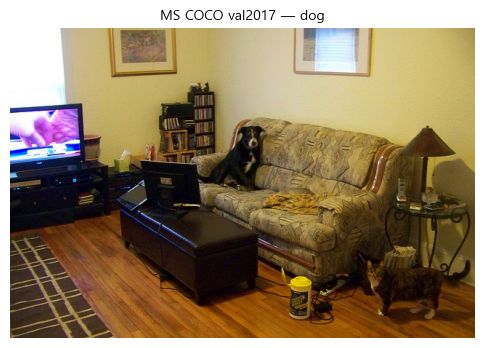

In [3]:
from dataclasses import dataclass

# COCO 공식 CDN — val2017 이미지를 개별 URL로 제공
COCO_IMAGE_BASE = "http://images.cocodataset.org/val2017/"

# MS COCO val2017 — 예제용 샘플만 URL로 지정 (전체 데이터셋 다운로드 불필요)
# file_name: COCO val2017 파일명, captions: 사람이 작성한 참고 캡션 (모델 결과 비교용)
COCO_SAMPLE_URLS: dict[str, dict] = {
    "dog": {
        "file_name": "000000543581.jpg",
        "image_id": 543581,
        "captions": [
            "A dog is sitting on the couch in a living room.",
            "A cute black dog sitting on the couch.",
        ],
    },
    "cat": {
        "file_name": "000000039769.jpg",
        "image_id": 39769,
        "captions": [
            "There are two cats laying down with two remotes",
            "Two cats sleeping with a remote control near each of them.",
        ],
    },
    "car": {
        "file_name": "000000527220.jpg",
        "image_id": 527220,
        "captions": [
            "A red car next to a gas station sign and parked blue and silver motorcycles.",
            "A red Ferrari at a gas station showing the gas prices and three mopeds",
        ],
    },
    "airplane": {
        "file_name": "000000001761.jpg",
        "image_id": 1761,
        "captions": [
            "Two planes flying in the sky over a bridge.",
            "Two planes fly over a bridge in Sydney, Australia, with the Sydney Opera House in the background.",
        ],
    },
}

COCO_SAMPLE_CATEGORIES = list(COCO_SAMPLE_URLS.keys())
_url_image_cache: dict[str, Image.Image] = {}  # 동일 URL 재요청 방지


@dataclass
class CocoSample:
    """COCO URL 샘플 1건 — 이미지 + 메타데이터"""
    image: Image.Image
    image_id: int
    category: str
    url: str
    captions: list[str]


def load_image_from_url(url: str) -> Image.Image:
    """URL에서 이미지 로드 (캐시 + User-Agent)"""
    if url in _url_image_cache:
        return _url_image_cache[url].copy()

    headers = {"User-Agent": "Qwen3-VL-Example-Notebook/1.0 (learning example)"}
    response = requests.get(url, timeout=30, headers=headers)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert("RGB")
    _url_image_cache[url] = image
    return image.copy()


def load_coco_sample_meta(category: str) -> CocoSample:
    """COCO val2017 URL에서 샘플 이미지 + 참고 캡션 반환"""
    if category not in COCO_SAMPLE_URLS:
        raise ValueError(
            f"등록되지 않은 카테고리 '{category}'. "
            f"사용 가능: {', '.join(COCO_SAMPLE_CATEGORIES)}"
        )
    meta = COCO_SAMPLE_URLS[category]
    url = COCO_IMAGE_BASE + meta["file_name"]
    image = load_image_from_url(url)
    return CocoSample(
        image=image,
        image_id=meta["image_id"],
        category=category,
        url=url,
        captions=meta["captions"],
    )


def load_coco_samples(categories: list[str]) -> list[CocoSample]:
    """여러 카테고리 샘플을 한꺼번에 로드"""
    return [load_coco_sample_meta(cat) for cat in categories]


def show_image(image: Image.Image, title: str = ""):
    """이미지 1장 표시 (고해상도 COCO용 figsize=6)"""
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    if title:
        plt.title(title, fontsize=10)
    plt.show()


# 예제용 강아지 이미지 로드 — 이후 섹션에서 `image`, `sample` 변수 재사용
sample = load_coco_sample_meta("dog")
image = sample.image
print(f"URL: {sample.url}")
print(f"COCO image_id={sample.image_id}, category={sample.category}, size={image.size}")
print(f"COCO 참고 캡션: {sample.captions[0]}")
show_image(image, f"MS COCO val2017 — {sample.category}")


## 4. 추론 헬퍼 함수

`apply_chat_template`으로 Qwen3 대화 형식을 맞추고, 입력 토큰 길이만큼 잘라 **assistant 응답만** 디코딩합니다.


In [4]:
def decode_generated(inputs, output_ids) -> str:
    """입력 프롬프트를 제외한 생성 토큰만 디코딩"""
    trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs["input_ids"], output_ids)
    ]
    texts = processor.batch_decode(
        trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )
    return texts[0].strip()


def _move_inputs_to_model(inputs: dict) -> dict:
    """텐서를 모델 디바이스·dtype에 맞게 이동"""
    model_device = next(model.parameters()).device
    moved = {}
    for key, value in inputs.items():
        if not hasattr(value, "to"):
            moved[key] = value
            continue
        if key == "pixel_values":
            moved[key] = value.to(model_device, dtype=dtype)  # 비전 입력은 fp16/bf16 맞춤
        else:
            moved[key] = value.to(model_device)
    return moved


def ask_qwen3_vl(
    question: str,
    *,
    image: Image.Image | None = None,
    image_url: str | None = None,
    conversation: list[dict] | None = None,
    max_new_tokens: int = 256,
    do_sample: bool = False,
    temperature: float = 0.7,
) -> str:
    """Qwen3-VL에 질문하고 assistant 응답 문자열을 반환.

    - `conversation`이 주어지면 다중 턴 대화로 처리
    - 그렇지 않으면 단일 턴: image_url 또는 image + question
    """
    if conversation is None:
        # 단일 턴: user 메시지에 이미지 + 텍스트 질문 구성
        content = []
        if image_url:
            content.append({"type": "image", "url": image_url})
        elif image is not None:
            content.append({"type": "image", "image": image})
        else:
            raise ValueError("image 또는 image_url 중 하나는 필요합니다.")
        content.append({"type": "text", "text": question})
        conversation = [{"role": "user", "content": content}]

    # Qwen3 <|im_start|>user/assistant 형식으로 프롬프트 구성 + 토큰화
    inputs = processor.apply_chat_template(
        conversation,
        add_generation_prompt=True,  # 마지막에 "<|im_start|>assistant" 추가
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs = _move_inputs_to_model(inputs)

    generate_kwargs = {"max_new_tokens": max_new_tokens}
    if do_sample:
        generate_kwargs.update({"do_sample": True, "temperature": temperature})

    with torch.no_grad():
        output_ids = model.generate(**inputs, **generate_kwargs)

    return decode_generated(inputs, output_ids)


print("헬퍼 함수 준비 완료")


헬퍼 함수 준비 완료


## 5. 이미지 설명 (한국어 단일 턴)

Qwen3-VL은 **한국어 질문·답변**을 네이티브로 처리합니다. LLaVA와 달리 별도 번역 없이 바로 사용할 수 있습니다.


질문: 이 이미지를 자세히 한국어로 설명해 주세요.
Qwen3-VL 답변:
이 이미지는 따뜻한 조명 아래, 편안한 가정의 거실을 담고 있습니다. 벽은 연한 베이지색으로, 창문 옆에는 흰색의 커튼이 있고, 그 옆에는 작은 프레임의 그림이 걸려 있습니다. 거실 중앙에는 패턴이 있는 소파가 자리 잡고 있으며, 소파 위에는 검은색과 흰색의 강아지가 앉아 있고, 그 옆에는 노란색의 천이 펼쳐져 있습니다. 소파 앞에는 검은색의 컨테이너형 테이블이 있고, 그 위에는 노트북이 놓여 있습니다. 테이블 옆에는 검은색의 TV가 있고, TV 화면에는 손이 보이는 영상이 재생되고 있습니다. TV 아래에는 검은색의 캐비닛이 있고, 그 옆에는 책장이 있습니다. 책장 위에는 여러 권의 책과 음반들이 진열되어 있습니다. 소파 오른쪽에는 검은색의 테이블이 있고,

COCO 참고 캡션(영어): A dog is sitting on the couch in a living room.


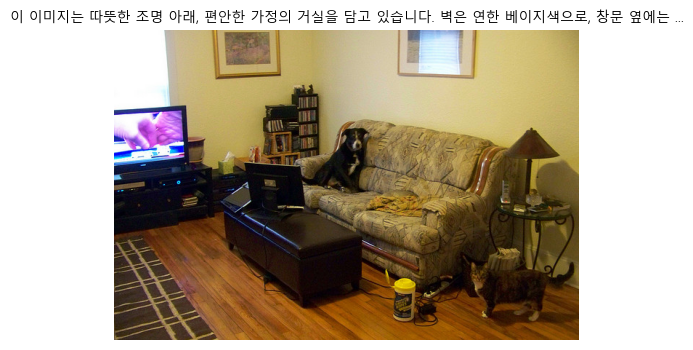

In [5]:
# 한국어 이미지 설명 — Qwen3-VL의 다국어 강점 확인
question = "이 이미지를 자세히 한국어로 설명해 주세요."
answer = ask_qwen3_vl(question, image_url=sample.url, max_new_tokens=256)

print(f"질문: {question}")
print(f"Qwen3-VL 답변:\n{answer}")
print(f"\nCOCO 참고 캡션(영어): {sample.captions[0]}")
show_image(image, answer[:60] + ("..." if len(answer) > 60 else ""))


## 6. Visual Question Answering (한국어 VQA)

같은 이미지에 여러 한국어 질문을 던져 세부 정보를 확인합니다.


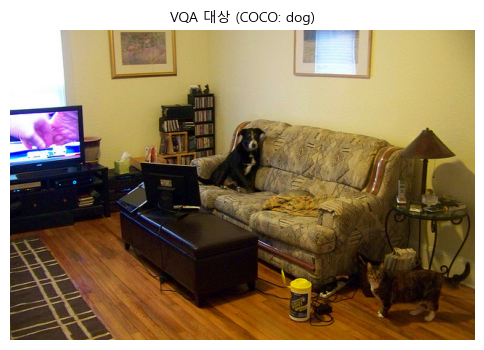

한국어 VQA 결과:
  Q: 이 사진에 어떤 동물이 있나요?
  A: 이 사진에는 **개**와 **고양이**가 있습니다.

- **개**: 소파 위에 앉아 있는 검은색과 흰색의 개가 보입니다.
- **고양이**: 소파 옆에 서 있는 갈색과 검은색 줄무늬가 있는 고양이가 보입니다.

두 동물 모두 사진 속에서 자연스럽게 배치되어 있습니다.

  Q: 동물은 어디에 앉아 있나요?
  A: 이 사진에서 동물은 **소파 위에 앉아 있습니다**.

- 소파는 방의 중앙에 위치하고 있으며, **검은색과 흰색의 강아지**가 그 위에 앉아 있습니다.
- 강아지는 소파의 **좌측 상단 부분**에 앉아 있으며, 앞발을 펴고 눈을 뜨고 있는 모습입니다.
- 소파의 오른쪽 아래에는 **고양이**도 보이지만, 그는 소파에 앉아 있지 않고 **바닥 위에 서 있습니다**

  Q: 강아지가 혼자인가요?
  A: 아니요, 강아지는 혼자 아닙니다. 이미지에서 강아지는 소파에 앉아 있으며, 그 옆에는 **고양이**가 있습니다. 고양이는 소파 근처에 서서 강아지의 주변을 둘러보는 모습이 보입니다. 따라서 강아지와 고양이는 함께 있는 상태입니다.

**답변: 아니요, 강아지는 혼자 아닙니다.**

  Q: 강아지의 주된 색깔은 무엇인가요?
  A: 강아지의 주된 색깔은 **검정**입니다.  
그림자와 흰색 부분이 있지만, 전체적으로 강아지는 검은색과 흰색이 섞인 **검정색**을 주로 보입니다.



In [6]:
# 같은 이미지에 여러 한국어 질문 — VQA(Visual Question Answering) 데모
questions = [
    "이 사진에 어떤 동물이 있나요?",
    "동물은 어디에 앉아 있나요?",
    "강아지가 혼자인가요?",
    "강아지의 주된 색깔은 무엇인가요?",
]

show_image(image, f"VQA 대상 (COCO: {sample.category})")
print("한국어 VQA 결과:")
for q in questions:
    ans = ask_qwen3_vl(q, image_url=sample.url, max_new_tokens=128)
    print(f"  Q: {q}")
    print(f"  A: {ans}")
    print()


## 7. 다중 턴 대화

첫 턴에서 이미지를 보여준 뒤, 이후 턴에서는 텍스트만으로 후속 질문을 이어갑니다.


In [7]:
# 첫 턴: 이미지 + 질문 (이후 턴은 텍스트만으로 맥락 유지)
conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": sample.url},
            {"type": "text", "text": "이 사진에 보이는 것을 간단히 한국어로 설명해 주세요."},
        ],
    },
]

first_answer = ask_qwen3_vl("", conversation=conversation, max_new_tokens=128)
print(f"[턴 1] A: {first_answer}")

# assistant 응답을 히스토리에 추가한 뒤 후속 질문
conversation.extend([
    {"role": "assistant", "content": [{"type": "text", "text": first_answer}]},
    {"role": "user", "content": [{"type": "text", "text": "강아지는 무엇을 하고 있나요?"}]},
])

second_answer = ask_qwen3_vl("", conversation=conversation, max_new_tokens=128)
print(f"[턴 2] Q: 강아지는 무엇을 하고 있나요?")
print(f"[턴 2] A: {second_answer}")

# 세 번째 턴: 추론이 필요한 개방형 질문
conversation.extend([
    {"role": "assistant", "content": [{"type": "text", "text": second_answer}]},
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "반려동물 입양 사이트에 올리기 좋은 사진일까요? 이유도 알려주세요.",
            }
        ],
    },
])

third_answer = ask_qwen3_vl("", conversation=conversation, max_new_tokens=200)
print(f"[턴 3] Q: 반려동물 입양 사이트에 올리기 좋은 사진일까요?")
print(f"[턴 3] A: {third_answer}")


[턴 1] A: 이 사진은 거실을 보여줍니다. 소파에 앉아 있는 검은색 강아지와 바닥에 서 있는 고양이가 보입니다. TV는 켜져 있고, 책장과 램프도 보입니다. 바닥에는 나무 바닥과 체크무늬 카펫이 있습니다.
[턴 2] Q: 강아지는 무엇을 하고 있나요?
[턴 2] A: 사진 속 강아지는 **소파에 앉아서 TV를 보고 있는 것** 같습니다.

강아지는 소파의 뒷부분에 앉아 있고, 앞쪽으로 몸을 돌리며 TV 방향을 바라보고 있습니다. 그의 시선은 TV 화면에 집중되어 있는 것처럼 보이며, TV에 나오는 이미지(손이 있는 장면)를 보고 있는 것처럼 보입니다. 강아지는 조용히 앉아 있고, 관심을 가지고 있는 듯한 자세를 취하고 있습니다.
[턴 3] Q: 반려동물 입양 사이트에 올리기 좋은 사진일까요?
[턴 3] A: **네, 이 사진은 반려동물 입양 사이트에 올리기 좋은 사진입니다.**  
다음 이유로 설명드릴게요:

---

### ✅ **1. 감정을 전달하는 따뜻한 분위기**
- 강아지가 소파에 앉아 TV를 보는 모습은 **편안하고 평온한 일상**을 보여줍니다.  
- 이는 “집에 들어와도 잘 적응하고, 사람과 함께 있는 모습을 즐긴다”는 **자기 자신을 잘 알 수 있는 동물**이라는 인상을 줍니다.  
- **사랑스럽고 따뜻한 분위기**는 입양자에게 ‘이 강아지와 함께 살 수 있을까?’라는 호기심을 자극합니다.

---

### ✅ **2. 자연스러운 행동과 표현**
- 강아지는 **자연스럽


## 8. 지시 따르기 — 다른 이미지로 추론 테스트

고양이 이미지로 **객체 나열**, **개수 세기** 등 구조화된 지시를 수행합니다.


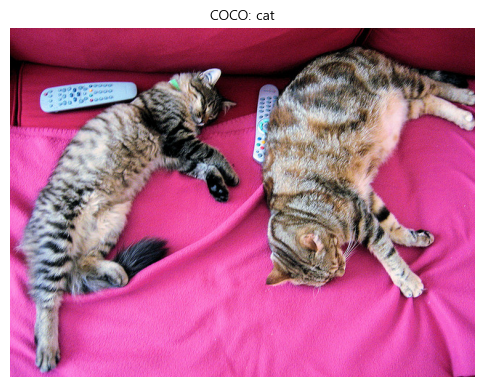

지시: 이 이미지에서 식별할 수 있는 모든 사물을 나열해 주세요.
응답: 이 이미지에서 식별할 수 있는 사물은 다음과 같습니다:

- **고양이 1마리**: 왼쪽에 누워 있는 고양이. 털은 줄무늬가 있고, 몸을 펴서 누워 있으며, 목에 녹색 끈이 걸려 있습니다.
- **고양이 2마리**: 오른쪽에 누워 있는 고양이. 털은 줄무늬가 있고, 몸을 펴서 누워 있으며, 머리가 아래로 향해 있습니다.
- **리모컨 1개**: 왼쪽 고양이 옆에 놓인 회색 리모컨.
- **리모컨 2개**: 오른쪽 고양이 옆에 놓인 회색 리모컨.
- **분홍색 침대 또는 소파**: 고양이들이 누워 있는 분홍색 표면.
------------------------------------------------------------
지시: 고양이가 몇 마리 보이나요? 숫자만 답해 주세요.
응답: 2
------------------------------------------------------------
지시: 전자기기가 있나요? 있다면 이름을 알려주세요.
응답: 네, 이미지에는 **리모컨**이 있습니다.

이미지에 보이는 **두 개의 리모컨**은 **TV 리모컨**으로 보이며, 각각 **밝은 회색**과 **밝은 파란색**으로 색상이 다릅니다. 두 리모컨은 분명히 **전자기기**로 분류되며, **TV**나 **무선 기기**를 제어하는 장치입니다.

### 이름:
- **TV 리모컨** (또는 **텔레비전 리모컨**)

이 리모컨들은
------------------------------------------------------------


In [8]:
cat_sample = load_coco_sample_meta("cat")
show_image(cat_sample.image, f"COCO: {cat_sample.category}")

# 구조화된 지시 — 객체 나열, 개수 세기, 특정 카테고리 탐지
tasks = [
    ("이 이미지에서 식별할 수 있는 모든 사물을 나열해 주세요.", 256),
    ("고양이가 몇 마리 보이나요? 숫자만 답해 주세요.", 32),
    ("전자기기가 있나요? 있다면 이름을 알려주세요.", 128),
]

for prompt, max_tokens in tasks:
    result = ask_qwen3_vl(prompt, image_url=cat_sample.url, max_new_tokens=max_tokens)
    print(f"지시: {prompt}")
    print(f"응답: {result}")
    print("-" * 60)


## 9. 배치 추론

여러 이미지에 동일한 질문을 한꺼번에 적용합니다. 배치 생성 시 `padding_side="left"`를 설정합니다.


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


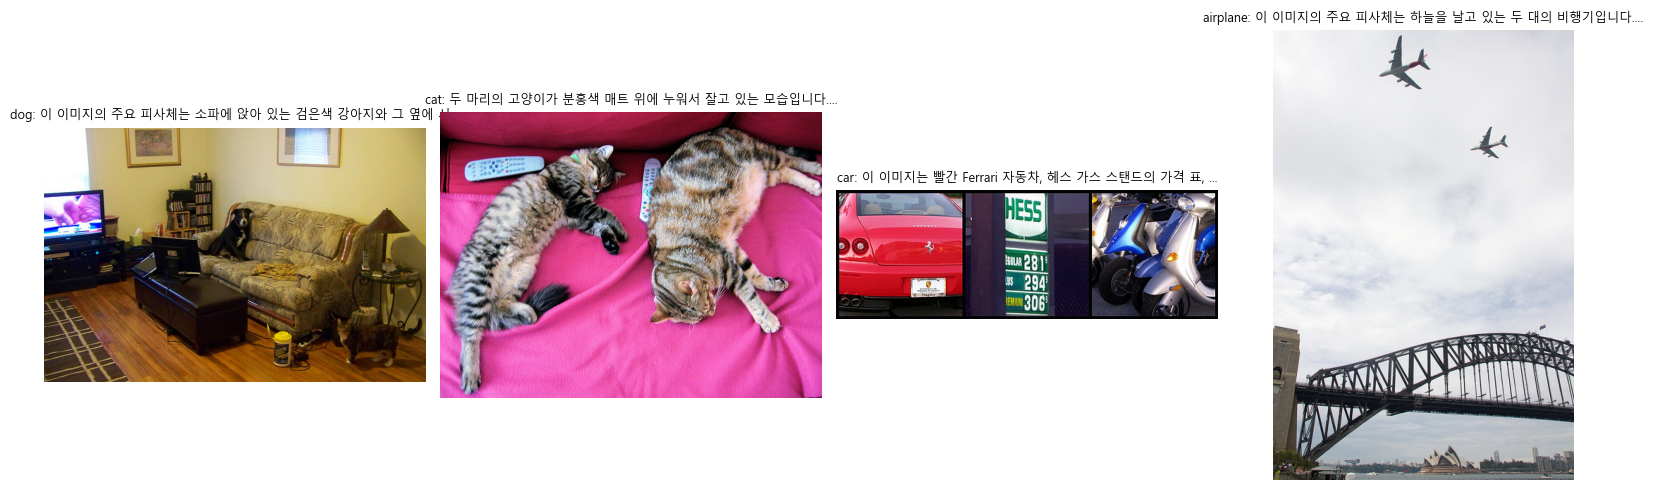

공통 질문: 이 이미지의 주요 피사체는 무엇인가요? 한 문장으로 답해 주세요.
  [dog] 이 이미지의 주요 피사체는 소파에 앉아 있는 검은색 강아지와 그 옆에 서 있는 고양이입니다.
  [cat] 두 마리의 고양이가 분홍색 매트 위에 누워서 잘고 있는 모습입니다.
  [car] 이 이미지는 빨간 Ferrari 자동차, 헤스 가스 스탠드의 가격 표, 그리고 파란색 스크린 자전거를 포함한 세 가지 다른 장면을 세로로 나란히 배열한 콜라주입니다.
  [airplane] 이 이미지의 주요 피사체는 하늘을 날고 있는 두 대의 비행기입니다.


In [9]:
# 배치 생성 시 왼쪽 패딩이 디코더 정확도에 유리 (transformers 권장)
processor.tokenizer.padding_side = "left"

batch_samples = load_coco_samples(["dog", "cat", "car", "airplane"])
question = "이 이미지의 주요 피사체는 무엇인가요? 한 문장으로 답해 주세요."

# 이미지마다 동일 질문의 대화 리스트 구성
conversations = []
for s in batch_samples:
    conversations.append([
        {
            "role": "user",
            "content": [
                {"type": "image", "url": s.url},
                {"type": "text", "text": question},
            ],
        }
    ])

inputs = processor.apply_chat_template(
    conversations,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    padding=True,  # 배치 내 시퀀스 길이 맞춤
    return_tensors="pt",
)
inputs = _move_inputs_to_model(inputs)

with torch.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=128)

# 배치별로 입력 길이만큼 trim 후 디코딩
decoded_batch = [
    decode_generated({"input_ids": inputs["input_ids"][i : i + 1]}, output_ids[i : i + 1])
    for i in range(len(batch_samples))
]

# 4장 이미지 + 답변을 한눈에 비교
fig, axes = plt.subplots(1, len(batch_samples), figsize=(16, 5))
if len(batch_samples) == 1:
    axes = [axes]

for ax, s, answer in zip(axes, batch_samples, decoded_batch):
    ax.imshow(s.image)
    ax.axis("off")
    ax.set_title(f"{s.category}: {answer[:40]}...", fontsize=9)

plt.tight_layout()
plt.show()

print(f"공통 질문: {question}")
for s, answer in zip(batch_samples, decoded_batch):
    print(f"  [{s.category}] {answer}")


## 10. 영어 질의 비교 (선택)

동일 이미지에 영어 질문을 던져 다국어 처리 능력을 확인합니다.


In [10]:
# 동일 이미지에 영어 질문 — 다국어 처리 능력 확인
en_question = "Describe this image in one concise English sentence."
en_answer = ask_qwen3_vl(en_question, image_url=sample.url, max_new_tokens=128)

print(f"English Q: {en_question}")
print(f"English A: {en_answer}")


English Q: Describe this image in one concise English sentence.
English A: A dog sits on a patterned couch in a cozy living room while a cat walks nearby, with a TV displaying a hand and a laptop on a coffee table.


## 11. LLaVA vs Qwen3-VL 비교 요약

| 항목 | LLaVA-7B (04번) | Qwen3-VL-4B (이 노트북) |
|------|-----------------|-------------------------|
| **핵심 구조** | CLIP-ViT + Vicuna LLM | Interleaved-MRoPE + DeepStack ViT + Qwen3 LLM |
| **파라미터** | 7B | 4B |
| **VRAM (fp16)** | ~14GB | ~8~10GB |
| **한국어 질문** | △ (영어 중심) | ✓ (네이티브 지원) |
| **한국어 답변** | △ | ✓ |
| **다중 턴 대화** | ✓ | ✓ |
| **OCR / 문서** | 제한적 | 32개 언어 OCR 강화 |
| **적합 용도** | 영어 복잡 추론·대화 | **한국어 VLM**, 경량 배포, OCR·문서 이해 |

**선택 가이드**
- **한국어 VQA·캡션** → Qwen3-VL (이 노트북)
- **영어 중심 다중 턴 대화·학습 파이프라인 체험** → LLaVA (`04`, `05`번)
- **분류·검색·유사도** → CLIP (`01_clip_example.ipynb`)
- **한국어 VLM 파인튜닝** → `vlm101-sft-hands-on-main/ko_sft_lora_qwen2.5vl.ipynb` 참고
